# Week 13 데이터 분석 실습 (shopping.csv)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RAKKUNN/ComputerProgramming01/blob/main/week13/q1.ipynb)

이 노트북은 `shopping.csv` 데이터를 로드하여 기본적인 데이터 가공, 분석 및 시각화를 수행하는 코랩 실습 가이드입니다.
지시사항에 따라 빈칸을 완성하고 코드를 실행하며 실습을 진행해 보세요.

## 0) 데이터셋 준비 및 환경 설정
- Google Colab 환경에서 동작할 수 있도록 `shopping.csv` 파일 자동 다운로드 코드를 실행합니다.
- 시각화 그래프 내 한글이 깨지지 않도록 한글 폰트(나눔바른고딕 등) 설정 과정을 수행합니다.

In [9]:
import os
import urllib.request
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# Colab 환경에서 실습 시 shopping.csv 파일이 없으면 자동으로 다운로드합니다.
if not os.path.exists("shopping.csv"):
    urls = [
        "https://raw.githubusercontent.com/RAKKUNN/ComputerProgramming01/main/week13/shopping.csv",
        "https://raw.githubusercontent.com/RAKKUNN/ComputerProgramming01/main/shopping.csv"
    ]
    downloaded = False
    for url in urls:
        try:
            print(f"shopping.csv 다운로드 시도 중: {url}")
            urllib.request.urlretrieve(url, "shopping.csv")
            print("다운로드 완료!")
            downloaded = True
            break
        except Exception as e:
            print(f"다운로드 실패: {e}")

    if not downloaded:
        print("\n[!] 자동 다운로드에 실패했습니다. 아래 업로드 버튼을 사용해 'shopping.csv' 파일을 직접 업로드해 주세요.")
        from google.colab import files
        uploaded = files.upload()

# 한글 폰트 설정 (Colab 및 로컬 환경에서 한글 깨짐 방지)
try:
    if 'google.colab' in str(get_ipython()):
        print("Google Colab 환경입니다. 한글 폰트를 설치합니다...")
        # 나눔 폰트 설치
        os.system("apt-get update -qq")
        os.system("apt-get install fonts-nanum -qq")
        import matplotlib.font_manager as fm
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False
        print(f"한글 폰트('{font_name}') 설정 완료. (그래프 내 한글이 깨질 경우 세션/런타임을 다시 시작해 주세요.)")
    else:
        if platform.system() == 'Darwin':
            plt.rc('font', family='AppleGothic')
        elif platform.system() == 'Windows':
            plt.rc('font', family='Malgun Gothic')
        plt.rcParams['axes.unicode_minus'] = False
except NameError:
    # 주피터 환경이 아닐 때의 예외 처리
    if platform.system() == 'Darwin':
        plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv("shopping.csv")
df.head()

Google Colab 환경입니다. 한글 폰트를 설치합니다...
한글 폰트('NanumGothic') 설정 완료. (그래프 내 한글이 깨질 경우 세션/런타임을 다시 시작해 주세요.)


,OrderID,OrderDate,Category,ProductName,UnitPrice,Quantity,Region
0,1001,2024-01-07,Fashion,Denim Jeans,18900.0,3,Incheon
1,1002,2024-01-20,Electronics,Portable Speaker,49000.0,2,Daejeon
2,1003,2024-01-29,Fashion,Hoodie,24900.0,1,Seoul
3,1004,2024-01-15,Home,Towel Set,55000.0,2,Daejeon
4,1005,2024-01-11,Electronics,Bluetooth Earbuds,39000.0,1,Seoul


## 1) 매출 열 추가
- 단가(`UnitPrice`)와 수량(`Quantity`)을 곱하여 `Revenue` (매출) 열을 데이터프레임에 추가하세요.

In [8]:
# 1) 매출 열 추가
df["Revenue"] = df["UnitPrice"] * df["Quantity"]
df.head()

,OrderID,OrderDate,Category,ProductName,UnitPrice,Quantity,Region,Revenue
0,1001,2024-01-07,Fashion,Denim Jeans,18900.0,3,Incheon,56700.0
1,1002,2024-01-20,Electronics,Portable Speaker,49000.0,2,Daejeon,98000.0
2,1003,2024-01-29,Fashion,Hoodie,24900.0,1,Seoul,24900.0
3,1004,2024-01-15,Home,Towel Set,55000.0,2,Daejeon,110000.0
4,1005,2024-01-11,Electronics,Bluetooth Earbuds,39000.0,1,Seoul,39000.0


## 2) 결측 확인 후 평균으로 대체
- 데이터프레임 내 결측값(NaN)을 확인하고 단가(`UnitPrice`)의 결측치를 평균 단가로 채웁니다.
- 결측값이 채워진 단가를 기준으로 매출(`Revenue`)을 다시 계산합니다.
- 실수의 출력 포맷을 소수점 없이 천 단위 쉼표가 붙도록 설정합니다.

In [13]:
# 2) 결측 확인 후 평균으로 대체

# 결측치 확인
print(df.isnull().sum()) # 데이터프레임의 결측치 합계 확인

# UnitPrice의 결측치를 UnitPrice의 평균값으로 대체
df["UnitPrice"] = df["UnitPrice"].mean()

# 단가를 채운 뒤 매출(Revenue) 다시 계산
df["Revenue"]   = df["UnitPrice"] * df["Quantity"]

# 실수형 데이터 출력 포맷 설정 (소수점 없이 천 단위 쉼표 표시)
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
df.head()

OrderID        0
OrderDate      0
Category       0
ProductName    0
UnitPrice      0
Quantity       0
Region         3
Revenue        0
dtype: int64


,OrderID,OrderDate,Category,ProductName,UnitPrice,Quantity,Region,Revenue
0,1001,2024-01-07,Fashion,Denim Jeans,"38,291",3,Incheon,"114,872"
1,1002,2024-01-20,Electronics,Portable Speaker,"38,291",2,Daejeon,"76,582"
2,1003,2024-01-29,Fashion,Hoodie,"38,291",1,Seoul,"38,291"
3,1004,2024-01-15,Home,Towel Set,"38,291",2,Daejeon,"76,582"
4,1005,2024-01-11,Electronics,Bluetooth Earbuds,"38,291",1,Seoul,"38,291"


## 3) 카테고리별 매출 합계/평균/건수
- 카테고리(`Category`)별 매출(`Revenue`)의 합계(sum), 평균(mean), 건수(count)를 집계하여 출력하세요.

In [16]:
# 3) 카테고리별 매출 합계/평균/건수
print(df.groupby("Category")["Revenue"].agg(["sum","mean","count"]))# 여기에 코드를 완성하세요: Category별 Revenue에 대한 sum, mean, count 집계)

                  sum   mean  count
Category                           
Beauty        804,107 53,607     15
Electronics 1,991,122 68,659     29
Fashion     1,033,852 68,923     15
Home        1,340,179 63,818     21
Sports      1,455,051 72,753     20


## 4) 카테고리별 평균 단가
- 카테고리(`Category`)별 단가(`UnitPrice`)의 평균을 집계하여 출력하세요.

In [17]:
# 4) 카테고리별 평균 단가
print(df.groupby("Category")["UnitPrice"].mean())# 여기에 코드를 완성하세요: Category별 UnitPrice의 평균 계산)

Category
Beauty        38,291
Electronics   38,291
Fashion       38,291
Home          38,291
Sports        38,291
Name: UnitPrice, dtype: float64


## 5) 카테고리별 매출 합계 막대그래프
- 카테고리(`Category`)별 매출(`Revenue`)의 합계를 구하여 데이터프레임으로 변환합니다.
- `seaborn` 라이브러리의 `barplot`을 사용하여 시각화(막대그래프)하고 제목 및 축 레이블을 설정합니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

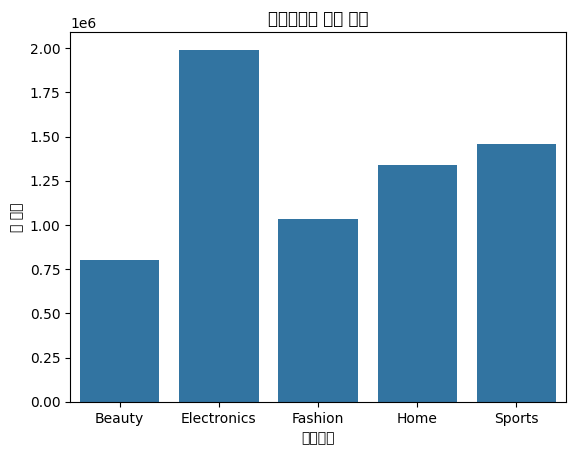

In [21]:
# 5) 카테고리별 매출 합계 막대그래프

# 카테고리별 매출 합계 계산 및 인덱스 리셋
cat_revenue = df.groupby("Category")["Revenue"].sum().reset_index()

# 막대그래프 시각화 (x축: 카테고리, y축: 매출합계)
sns.barplot(data=cat_revenue, x="Category", y="Revenue")

# 그래프 서식 설정
plt.title('카테고리별 매출 합계')
plt.xlabel('카테고리')
plt.ylabel('총 매출')
plt.show()